<a href="https://colab.research.google.com/github/Ali-Hamza-developer/pytorch/blob/main/05_training_pipeline_using_nn_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Classification — Full Training Pipeline with `nn.Module`

**Ali Hamza**
🔗 [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)

---

This notebook is the "production" version of the manual notebook from earlier. Same dataset, same goal (classify tumors as **Malignant** or **Benign**), but this time the model, loss, and parameter updates are all handled by PyTorch's built-in tools:

| | Manual notebook | This notebook |
|---|---|---|
| Model | hand-written `class` with raw tensors | `nn.Module` + `nn.Linear` |
| Weights & bias | `torch.rand(...)`, `torch.zeros(...)` | created automatically inside `nn.Linear` |
| Loss | hand-written Binary Cross-Entropy formula | `nn.BCELoss()` |
| Parameter update | `weights -= lr * weights.grad` (manual) | `optimizer.step()` (`torch.optim.SGD`) |
| Zero gradients | `.grad.zero_()` on each param | `optimizer.zero_grad()` |

The data pipeline (loading, cleaning, splitting, scaling, encoding) is identical to before — that part doesn't change no matter which style of model you build.

### 🔄 Full pipeline overview

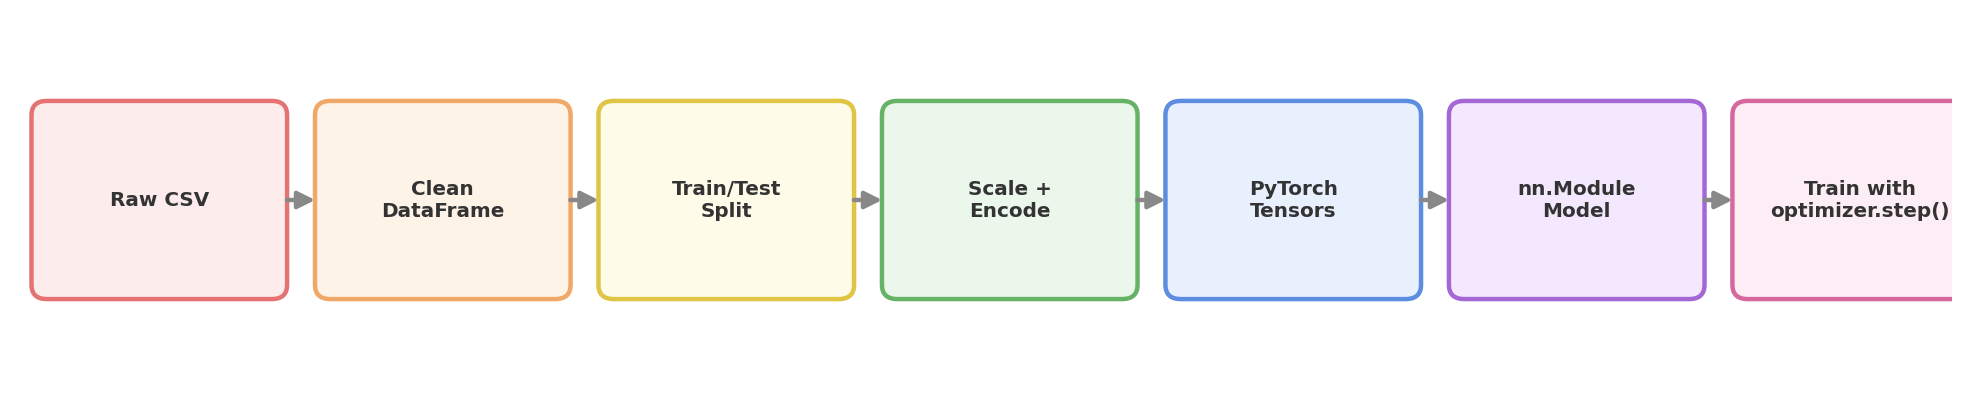

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

## Step 2 — Load the Dataset

In [2]:
# load dataset directly from a CSV hosted on GitHub
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

# quick look at the first few rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# check dataset size: (rows, columns)
df.shape

(569, 33)

### Cleaning the data

- `id` → just a row identifier, no predictive value
- `Unnamed: 32` → empty leftover column from the CSV export

> ⚠️ **Common mistake:** forgetting to drop `id` lets the model "cheat" by memorizing ID numbers instead of learning real patterns.

In [4]:
# remove unnecessary columns permanently (inplace=True)
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

# confirm the columns are gone
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 3 — Train / Test Split

`X` = all feature columns, `y` = the `diagnosis` label. `test_size=0.2` → 80% train, 20% test, so the model is evaluated on data it never trained on.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

## Step 4 — Feature Scaling

Features are on very different numeric ranges (e.g. `area_mean` in the hundreds vs `smoothness_mean` as a small decimal). `StandardScaler` rescales every feature to **mean = 0, std = 1**, which helps the model train faster and more stably.

> ⚠️ **Important rule:** fit the scaler only on `X_train` (`fit_transform`), then just `transform` `X_test` — never re-fit on test data, or information leaks from test into training.

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn mean/std from training data, then scale it
X_test = scaler.transform(X_test)         # apply the SAME scaling to test data (no re-fitting)

In [7]:
# scaled X_train — values are now centered around 0
X_train

array([[-0.95640287,  0.67651236, -0.96697709, ..., -0.61898364,
         0.13173592, -0.41983037],
       [-0.16109515,  0.64346063, -0.20600188, ..., -0.81886221,
        -0.73036132, -0.78633351],
       [ 0.4831326 ,  1.14159742,  0.47916579, ..., -0.04757153,
        -0.12739157, -1.20970784],
       ...,
       [-1.09323   , -0.65263936, -1.1111357 , ..., -1.40615973,
        -0.340009  , -0.57091239],
       [-0.07272763,  0.02964278, -0.1409648 , ..., -0.51642249,
        -0.87985795, -0.45372329],
       [ 1.53214062,  3.15303129,  1.48579059, ...,  0.73281856,
        -0.28685465, -0.47382927]])

In [8]:
# y_train is still text labels ('M' / 'B') at this point
y_train

,diagnosis
427,B
267,B
13,M
344,B
131,M
...,...
378,B
307,B
546,B
481,B


## Step 5 — Label Encoding

PyTorch needs numbers, not text. `LabelEncoder` converts diagnosis labels into numbers — `M` → `1`, `B` → `0` (mapping decided alphabetically by scikit-learn).

In [9]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)   # learn the mapping + apply it
y_test = encoder.transform(y_test)         # apply the SAME mapping to test labels

In [10]:
# y_train is now an array of 0s and 1s
y_train

array([0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

## Step 6 — Convert NumPy Arrays to PyTorch Tensors

`torch.from_numpy()` converts an array to a tensor while keeping the same underlying data.

> ⚠️ **Note the `.astype(np.float32)` here:** `nn.Linear` and `nn.BCELoss` expect `float32` tensors by default. NumPy/pandas often default to `float64`, which causes a dtype-mismatch error inside PyTorch layers — converting explicitly avoids that.

In [11]:
X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.astype(np.float32))
y_test_tensor = torch.from_numpy(y_test.astype(np.float32))

In [12]:
# shape check: (455 training samples, 30 features)
X_train_tensor.shape

torch.Size([455, 30])

In [13]:
# shape check for the labels — a flat 1D tensor of 455 values
y_train_tensor.shape

torch.Size([455])

## Step 7 — Defining the Model with `nn.Module`

Same single-neuron idea as the manual notebook — 30 inputs, one output, sigmoid activation — but now `nn.Linear` creates and manages the weights and bias internally.

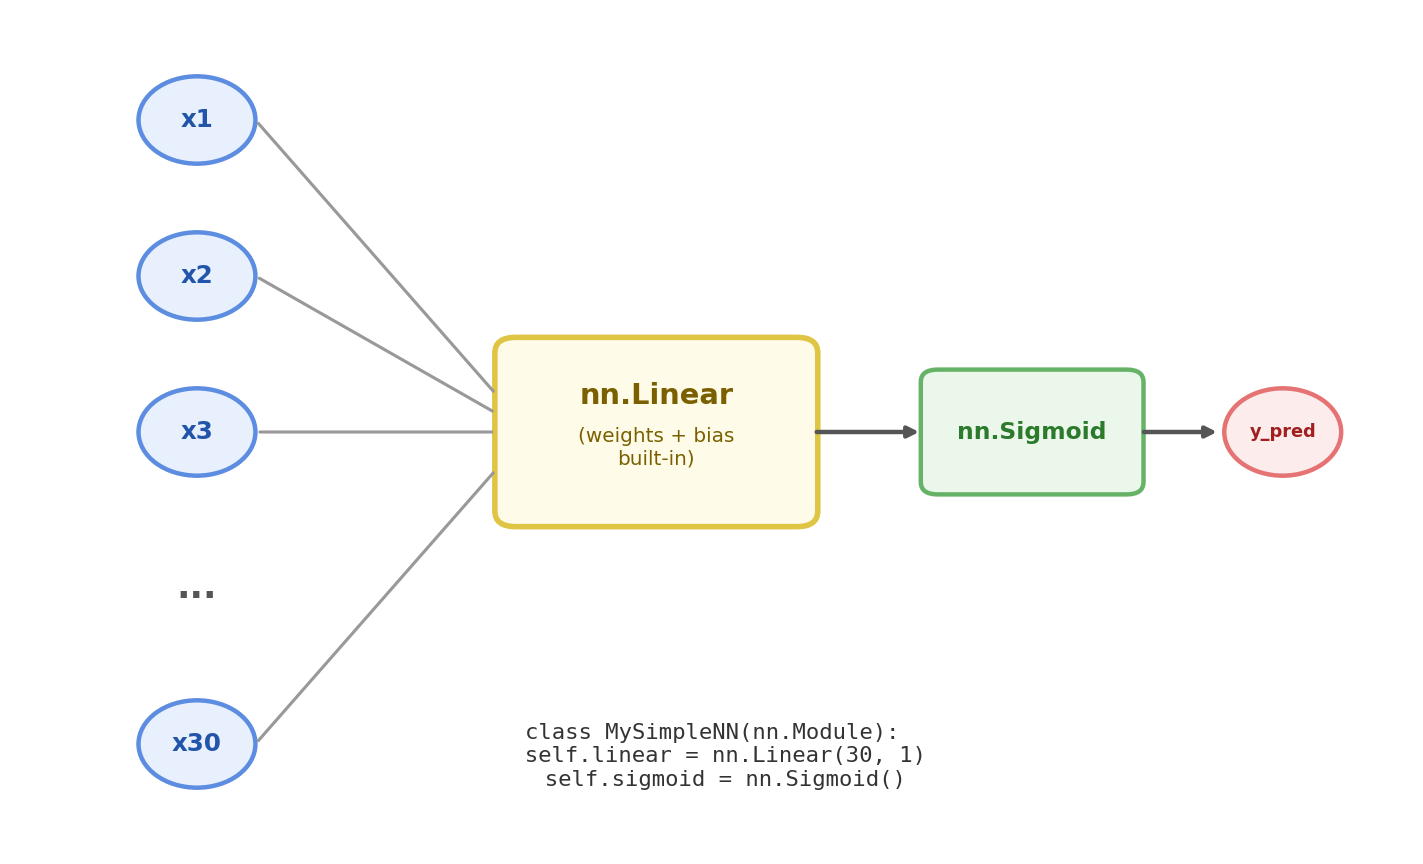

**What changed vs. the manual version:**
- `nn.Module` — the base class every PyTorch model inherits from; `super().__init__()` must run first so it can register the layers as trainable parameters
- `nn.Linear(num_features, 1)` — replaces the manual `torch.rand(...)` weights and `torch.zeros(...)` bias; both are created automatically and are already tracked for gradients
- `nn.Sigmoid()` — same role as before, squashes the output into a 0–1 probability
- `forward()` — still defines how data flows through the model, same as the manual version

In [14]:
import torch.nn as nn

class MySimpleNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.linear = nn.Linear(num_features, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):

    out = self.linear(features)
    out = self.sigmoid(out)

    return out

## Step 8 — Important Parameters

- **`learning_rate`** — step size for each parameter update. Too high → training becomes unstable; too low → training is very slow.
- **`epochs`** — how many full passes through the training data.

In [15]:
learning_rate = 0.1
epochs = 100

## Step 9 — Loss Function

Instead of writing the Binary Cross-Entropy formula by hand (with manual `clamp` to avoid `log(0)`), `nn.BCELoss()` does the same job as a ready-made, numerically stable PyTorch object.

> 💡 `BCELoss` expects the model's output to already be a probability (i.e. already passed through `Sigmoid`) — which is exactly what this model's `forward()` returns.

In [16]:
# define loss function
loss_function = nn.BCELoss()

## Step 10 — Training Pipeline

The same 5-step training cycle as before, but three of those steps are now one-liners handled by PyTorch:

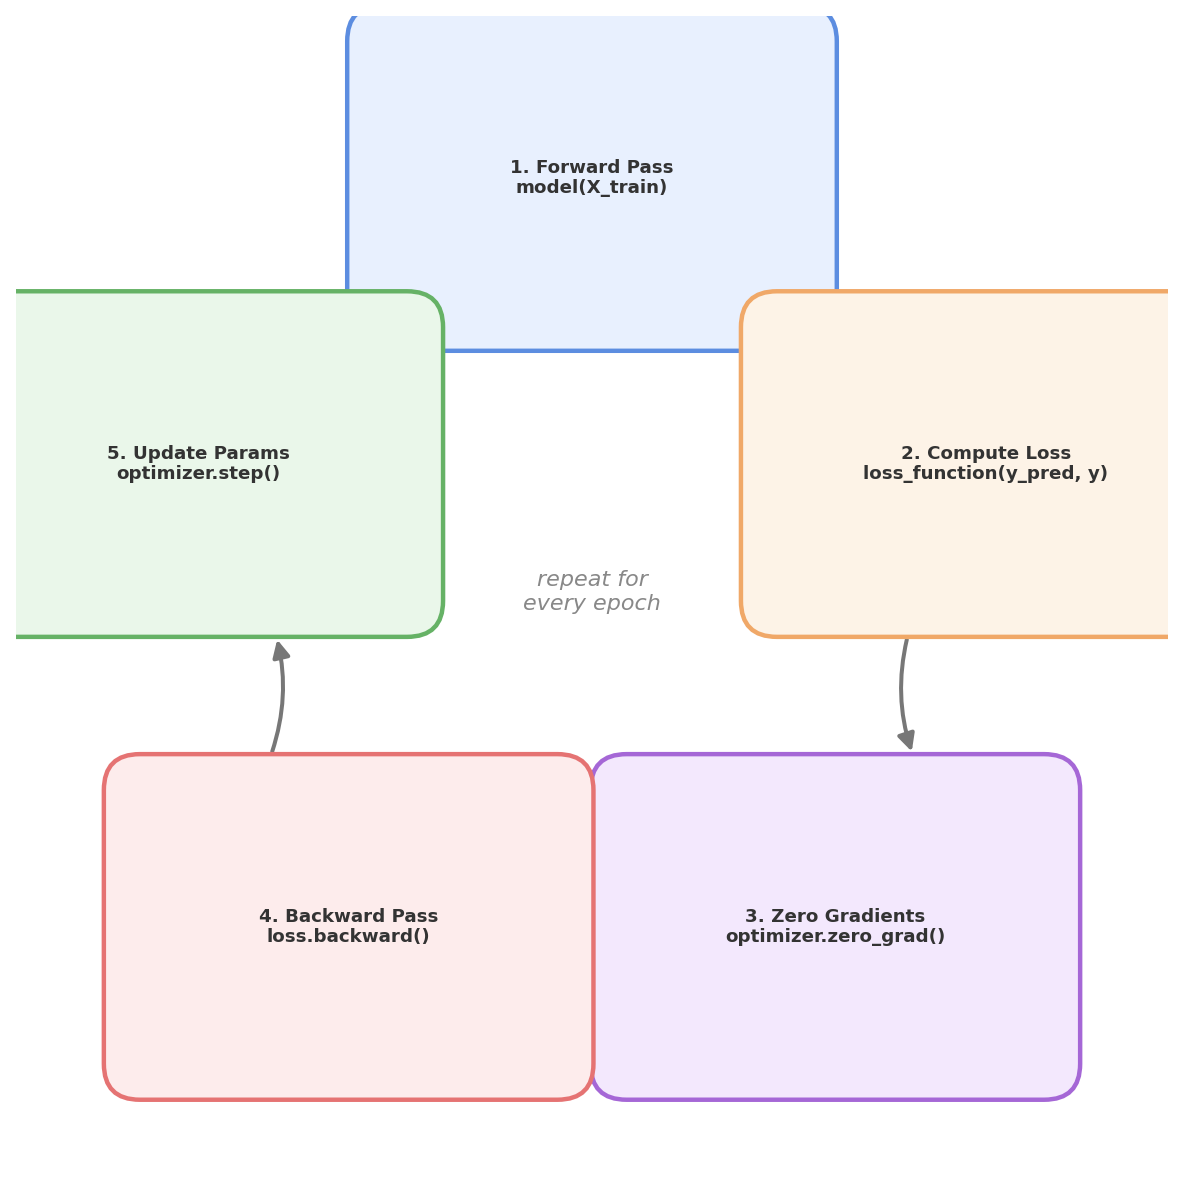

1. **Forward pass** — `model(X_train_tensor)` runs the data through `forward()` automatically (this is the same as calling `.forward()` directly, just the standard PyTorch convention)
2. **Compute loss** — `loss_function(y_pred, y)` replaces the manual BCE formula
3. **Zero gradients** — `optimizer.zero_grad()` clears old gradients *before* this epoch's backward pass, so they don't accumulate from the previous epoch
4. **Backward pass** — `loss.backward()`, same as before — computes gradients for every tracked parameter
5. **Update parameters** — `optimizer.step()` replaces the manual `weights -= learning_rate * weights.grad` line; the optimizer already knows the learning rate and which parameters to update, because both were given to it when it was created

> ⚠️ **Shape note:** `y_train_tensor` has shape `[455]` (1D) but the model's output `y_pred` has shape `[455, 1]` (2D). `loss_function` needs both to match, so `y_train_tensor.view(-1, 1)` reshapes it to `[455, 1]` right before comparing.

In [17]:
# create model
model = MySimpleNN(X_train_tensor.shape[1])

# define optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# define loop
for epoch in range(epochs):

  # forward pass
  y_pred = model(X_train_tensor)

  # loss calculate
  loss = loss_function(y_pred, y_train_tensor.view(-1,1))

  # clear gradients
  optimizer.zero_grad()

  # backward pass
  loss.backward()

  # parameters update
  optimizer.step()

  # print loss in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

Epoch: 1, Loss: 0.8621184229850769
Epoch: 2, Loss: 0.6031321287155151
Epoch: 3, Loss: 0.47649863362312317
Epoch: 4, Loss: 0.4073699712753296
Epoch: 5, Loss: 0.36304542422294617
Epoch: 6, Loss: 0.3315804600715637
Epoch: 7, Loss: 0.3077552318572998
Epoch: 8, Loss: 0.28890150785446167
Epoch: 9, Loss: 0.27349770069122314
Epoch: 10, Loss: 0.26060473918914795
Epoch: 11, Loss: 0.24960751831531525
Epoch: 12, Loss: 0.2400839477777481
Epoch: 13, Loss: 0.23173336684703827
Epoch: 14, Loss: 0.22433486580848694
Epoch: 15, Loss: 0.21772204339504242
Epoch: 16, Loss: 0.21176661550998688
Epoch: 17, Loss: 0.20636801421642303
Epoch: 18, Loss: 0.20144587755203247
Epoch: 19, Loss: 0.19693534076213837
Epoch: 20, Loss: 0.19278313219547272
Epoch: 21, Loss: 0.1889452189207077
Epoch: 22, Loss: 0.18538469076156616
Epoch: 23, Loss: 0.18207044899463654
Epoch: 24, Loss: 0.17897601425647736
Epoch: 25, Loss: 0.1760787069797516
Epoch: 26, Loss: 0.17335893213748932
Epoch: 27, Loss: 0.17079973220825195
Epoch: 28, Loss: 0

> 📉 **What to look for:** the printed loss should trend downward epoch over epoch. If it doesn't, `learning_rate` is usually the first thing to check.

## Step 11 — Model Evaluation

Testing on `X_test_tensor` — data the model has never seen during training.

- `torch.no_grad()` — disables gradient tracking since evaluation doesn't need it
- predictions above `0.5` are classified as `1` (Malignant), otherwise `0` (Benign) — the standard threshold (the manual notebook used a stricter `0.9`)
- **accuracy** = fraction of predictions matching the true label

In [18]:
# model evaluation
with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred = (y_pred > 0.5).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')

Accuracy: 0.5323176383972168


---

## ✅ Summary

- Same data pipeline as the manual notebook: load → clean → split → scale → encode → tensors
- Model rebuilt with `nn.Module` + `nn.Linear` — weights and bias are created and tracked automatically
- Manual BCE formula replaced with `nn.BCELoss()`
- Manual gradient-descent update replaced with `torch.optim.SGD` + `optimizer.step()`
- Training loop shrinks from ~10 manual lines of parameter math to 2 calls: `optimizer.zero_grad()` and `optimizer.step()`

**Why learn the manual version first?** Because this is exactly what `nn.Linear`, `nn.BCELoss`, and `optimizer.step()` are doing *underneath* — now that the internals are understood, the shortcuts make sense instead of feeling like magic.

**Where to go from here:** swap `MySimpleNN` for the deeper `nn.Sequential` models from the previous notebook (hidden layers + ReLU) and re-run this exact same training pipeline — nothing else needs to change.

---
**Ali Hamza** · [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)